In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('/Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Porject_3_AI_ML_Part_1/toxicity_per_attribute.csv')

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_30655/215964179.py:1: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/lukecheng/OMSCS/CS6603/CS6603_2026_Summer/Porject_3_AI_ML_Part_1/toxicity_per_attribute.csv')


Step 1: Data Clean up

In [3]:
# get number of row and columns we have
print(df.shape[0])
print(df.shape[1])

76565
52


In [4]:
# check null value for each column

print(df.isnull().sum().sort_values(ascending=False))

Wiki_ID             2
sikh                1
indian              1
middle eastern      1
chinese             1
japanese            1
christian           1
muslim              1
jewish              1
buddhist            1
catholic            1
protestant          1
taoist              1
american            1
old                 1
older               1
young               1
younger             1
teenage             1
millenial           1
middle aged         1
elderly             1
blind               1
deaf                1
asian               1
canadian            1
male                1
mexican             1
lesbian             1
gay                 1
bisexual            1
transgender         1
trans               1
queer               1
lgbt                1
lgbtq               1
homosexual          1
straight            1
heterosexual        1
paralyzed           1
female              1
nonbinary           1
african             1
african american    1
black               1
white     

In [5]:
# check null value for each row

print(df.isnull().sum(axis=1).sort_values(ascending=False))

52671    51
52672     1
0         0
51040     0
51046     0
         ..
25521     0
25520     0
25519     0
25518     0
76564     0
Length: 76565, dtype: int64


In [6]:
# Drop corrupted row
df = df[df['TOXICITY'] != 52671]

# Assign missing Wiki_ID
df.loc[df['Wiki_ID'].isna(), 'Wiki_ID'] = 52671

In [7]:
# check null value for each row

print(df.isnull().sum(axis=1).sort_values(ascending=False))

0        0
51049    0
51047    0
51046    0
51045    0
        ..
25520    0
25519    0
25518    0
25517    0
76564    0
Length: 76564, dtype: int64


Step 2: 

2.1 Create a new dataframe with rows that is not all FALSE


In [8]:
subgroup_cols = [c for c in df.columns if c not in ['Wiki_ID', 'TOXICITY']]
df_reduced = df[df[subgroup_cols].eq(True).any(axis=1)].copy()
print(f"Original: {len(df)} rows")
print(f"Reduced:  {len(df_reduced)} rows")
print(f"Removed:  {len(df) - len(df_reduced)} rows")

Original: 76564 rows
Reduced:  75700 rows
Removed:  864 rows


### Step 2.2 & 2.3: Encode subgroups and compact into protected class columns

Alphabetical encoding: `0` = FALSE, `1+` = subgroup (A–Z). If multiple subgroups in a class are TRUE, use the **highest** value.

In [9]:
# Alphabetical subgroup -> numeric value mappings (0 = FALSE)
protected_class_mappings = {
    'Gender': {
        'female': 1, 'male': 2, 'nonbinary': 3, 'trans': 4, 'transgender': 5
    },
    'Sexual Orientation': {
        'bisexual': 1, 'gay': 2, 'heterosexual': 3, 'homosexual': 4, 'lesbian': 5,
        'lgbt': 6, 'lgbtq': 7, 'queer': 8, 'straight': 9
    },
    'Race': {
        'african': 1, 'african american': 2, 'asian': 3, 'black': 4,
        'indian': 5, 'middle eastern': 6, 'white': 7
    },
    'Ethnicity': {
        'european': 1, 'hispanic': 2, 'latina': 3, 'latino': 4, 'latinx': 5
    },
    'National Origin': {
        'american': 1, 'canadian': 2, 'chinese': 3, 'japanese': 4, 'mexican': 5
    },
    'Religion': {
        'buddhist': 1, 'catholic': 2, 'christian': 3, 'jewish': 4, 'muslim': 5,
        'protestant': 6, 'sikh': 7, 'taoist': 8
    },
    'Age': {
        'elderly': 1, 'middle aged': 2, 'millenial': 3, 'old': 4, 'older': 5,
        'teenage': 6, 'young': 7, 'younger': 8
    },
    'Disability': {
        'blind': 1, 'deaf': 2, 'paralyzed': 3
    }
}


def compact_protected_class(df, subgroup_mapping):
  """Combine subgroup boolean columns into one encoded protected-class column."""
  values = np.zeros(len(df), dtype=int)
  for subgroup, code in subgroup_mapping.items():
    is_true = df[subgroup].eq(True)
    values = np.where(is_true, np.maximum(values, code), values)
  return values

In [10]:
# Build compacted dataset: Wiki_ID, TOXICITY, + one column per protected class
df_compacted = df_reduced[['Wiki_ID', 'TOXICITY']].copy()

for class_name, mapping in protected_class_mappings.items():
    df_compacted[class_name] = compact_protected_class(df_reduced, mapping)

print(df_compacted.shape)
df_compacted.head()

(75700, 10)


,Wiki_ID,TOXICITY,Gender,Sexual Orientation,Race,Ethnicity,National Origin,Religion,Age,Disability
0,0.0,0.096492,0,0,0,0,1,0,0,0
1,1.0,0.017991,4,0,0,0,0,0,0,0
2,2.0,0.150298,0,4,0,0,0,0,0,0
3,3.0,0.065861,0,0,0,0,5,0,0,0
4,4.0,0.667166,0,0,0,0,0,7,0,0


In [11]:
# Verify value ranges per protected class (0 = no subgroup mentioned)
for class_name in protected_class_mappings:
    print(f"{class_name}: min={df_compacted[class_name].min()}, max={df_compacted[class_name].max()}, unique={sorted(df_compacted[class_name].unique())}")

Gender: min=0, max=5, unique=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Sexual Orientation: min=0, max=9, unique=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Race: min=0, max=7, unique=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Ethnicity: min=0, max=5, unique=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
National Origin: min=0, max=5, unique=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Religion: min=0, max=8, unique=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Age: min=0, max=8, unique=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Disability: min=0, max=3, unique=[np.int64(0), np.int64(1), np.int6

Step 2.4 - Check corelation for each protected class

In [12]:
df_corr = df_compacted.corr()
print(df_corr)

                     Wiki_ID  TOXICITY    Gender  Sexual Orientation  \
Wiki_ID             1.000000  0.047838  0.004802           -0.005340   
TOXICITY            0.047838  1.000000  0.050751            0.130906   
Gender              0.004802  0.050751  1.000000           -0.121492   
Sexual Orientation -0.005340  0.130906 -0.121492            1.000000   
Race               -0.003572 -0.082510 -0.106014           -0.144541   
Ethnicity           0.004424  0.001963 -0.089109           -0.121492   
National Origin    -0.003781 -0.085213 -0.094694           -0.129107   
Religion            0.000257  0.017964 -0.113886           -0.155274   
Age                 0.001342 -0.032698 -0.113886           -0.155274   
Disability          0.003677  0.012026 -0.069507           -0.094767   

                        Race  Ethnicity  National Origin  Religion       Age  \
Wiki_ID            -0.003572   0.004424        -0.003781  0.000257  0.001342   
TOXICITY           -0.082510   0.001963        

Now we found that Sexual Orientation, National Origin, and Race are the Top 3. now we plot them as 2.5

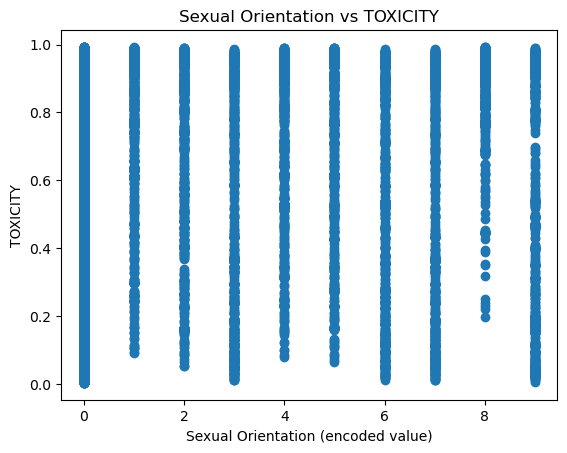

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df_compacted['Sexual Orientation'], df_compacted['TOXICITY'])
plt.xlabel('Sexual Orientation (encoded value)')
plt.ylabel('TOXICITY')
plt.title('Sexual Orientation vs TOXICITY')
plt.show()

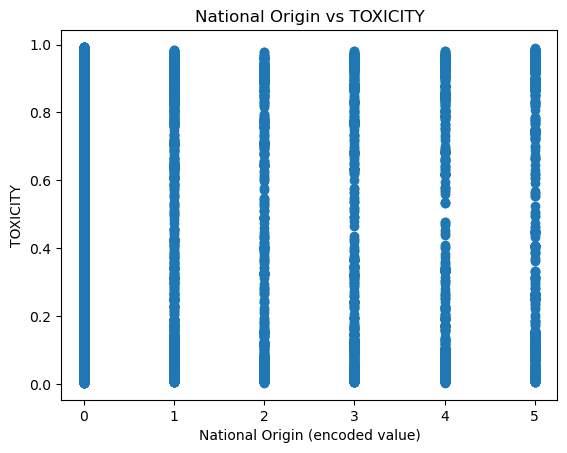

In [14]:
plt.scatter(df_compacted['National Origin'], df_compacted['TOXICITY'])
plt.xlabel('National Origin (encoded value)')
plt.ylabel('TOXICITY')
plt.title('National Origin vs TOXICITY')
plt.show()

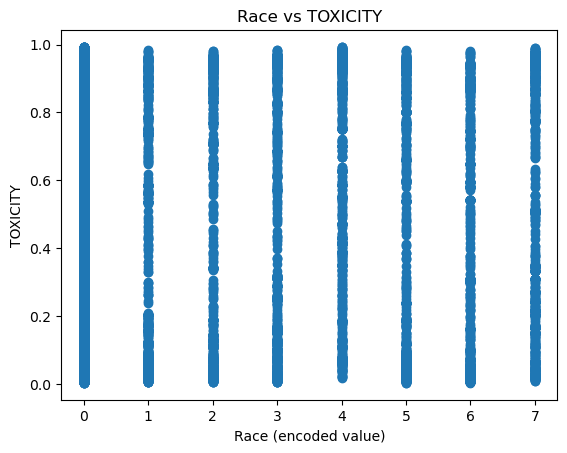

In [15]:
plt.scatter(df_compacted['Race'], df_compacted['TOXICITY'])
plt.xlabel('Race (encoded value)')
plt.ylabel('TOXICITY')
plt.title('Race vs TOXICITY')
plt.show()

Step 3: Analyzing Toxicity on Reduced Dataset

3.1 
- calculate mean and population standard dev of TOXICITY
- List the range of values of mean that includes 95% TOXICITY

In [23]:
mean = df_reduced['TOXICITY'].mean()
std_dev = df_reduced['TOXICITY'].std(ddof=0)

# to find range, get 2 stand dev above and below mean
double_std = std_dev*2
lower = mean-double_std
upper = mean+double_std


print('mean:',mean)
print('standard deviation:', std_dev)
print('range: ', lower, upper)

mean: 0.550101802360502
standard deviation: 0.36185007482613896
range:  -0.17359834729177592 1.27380195201278


3.2

In [24]:
small_sample = df_reduced.sample(frac=0.10, random_state=0)
mean = small_sample['TOXICITY'].mean()
std_dev = small_sample['TOXICITY'].std(ddof=0)
margin_error = 2 * (std_dev / np.sqrt(len(small_sample)))

print('mean:',mean)
print('standard deviation:', std_dev)
print('margin of error: ', margin_error)

mean: 0.556322766956539
standard deviation: 0.3621200635972302
margin of error:  0.008324049303570698


3.3

In [28]:
big_sample = df_reduced.sample(frac=0.60, random_state=0)
mean = big_sample['TOXICITY'].mean()
std_dev = big_sample['TOXICITY'].std(ddof=0)
margin_error = 2 * (std_dev / np.sqrt(len(big_sample)))

print('mean:',mean)
print('standard deviation:', std_dev)
print('margin of error: ', margin_error)

mean: 0.5513382534439233
standard deviation: 0.3616727177771927
margin of error:  0.0033940808265805326


Step 4


In [ ]:
# 4.1 Using 'Gender' protected class and True only data

gender_cols = ['female', 'male', 'nonbinary', 'trans', 'transgender']

gender_subset = df_reduced[df_reduced[gender_cols].eq(True).any(axis=1)]

gender_mean = gender_subset['TOXICITY'].mean()
gender_std = gender_subset['TOXICITY'].std(ddof=0)

print('mean:',gender_mean)
print('standard deviation:', gender_std)
print('n =', len(gender_subset))

mean: 0.5984416701509908
standard deviation: 0.34264019191400086
n = 7570


In [ ]:
# 4.2

gender_sample_small = small_sample[small_sample[gender_cols].eq(True).any(axis=1)]

sample_mean = gender_sample_small['TOXICITY'].mean()
sample_std = gender_sample_small['TOXICITY'].std(ddof=0)
n = len(gender_sample_small)
margin_error = 2 * (sample_std / np.sqrt(n))


print('mean:',sample_mean)
print('standard deviation:', sample_std)
print('margin of error', margin_error)

# Yes/No check (uses 4.1 population std)
comparison_moe = 2 * (gender_std / np.sqrt(n))
lower = gender_mean - comparison_moe
upper = gender_mean + comparison_moe
within = lower <= sample_mean <= upper
print("Yes" if within else "No")


mean: 0.5986179938276786
standard deviation: 0.34419413477263155
margin of error 0.010284766926133681
Yes


yes.
The sample mean fell within pop_mean ± comparison_moe, so the 10% gender subsample is consistent with the full gender population mean. Differences are within expected sampling variation.

In [36]:
# 4.3

gender_sample_big = big_sample[big_sample[gender_cols].eq(True).any(axis=1)]

sample_mean = gender_sample_big['TOXICITY'].mean()
sample_std = gender_sample_big['TOXICITY'].std(ddof=0)
n = len(gender_sample_big)
margin_error = 2 * (sample_std / np.sqrt(n))


print('mean:',sample_mean)
print('standard deviation:', sample_std)
print('margin of error', margin_error)

# Yes/No check (uses 4.1 population std)
comparison_moe = 2 * (gender_std / np.sqrt(n))
lower = gender_mean - comparison_moe
upper = gender_mean + comparison_moe
within = lower <= sample_mean <= upper
print("Yes" if within else "No")


mean: 0.5986179938276786
standard deviation: 0.34419413477263155
margin of error 0.010284766926133681
Yes


Yes. The 60% gender sample mean (≈0.599) lies within the margin of error around the population mean (≈0.598). The larger sample size reduces sampling error, so the sample mean is very close to the true gender population mean.

Step 5

In [37]:
# 5.1 - population mean and std per gender subgroup (df_reduced, one subgroup at a time)
gender_pop_stats = {}

for col in gender_cols:
    subgroup = df_reduced[df_reduced[col].eq(True)]
    gender_pop_stats[col] = {
        'mean': subgroup['TOXICITY'].mean(),
        'std': subgroup['TOXICITY'].std(ddof=0),
        'n': len(subgroup)
    }

gender_subgroup_pop = pd.DataFrame.from_dict(gender_pop_stats, orient='index')
gender_subgroup_pop.columns = ['Mean', 'Std Dev', 'n']
gender_subgroup_pop.index.name = 'Subgroup'
gender_subgroup_pop

,Mean,Std Dev,n
Subgroup,,,
female,0.603425,0.336896,1514
male,0.585090,0.337665,1514
nonbinary,0.555164,0.344433,1514
trans,0.507426,0.379844,1514
transgender,0.741103,0.256646,1514


In [38]:
# 5.2 - 10% sample stats per gender subgroup (uses small_sample from Step 3.2)
gender_sample_10_stats = {}

for col in gender_cols:
    subgroup_sample = small_sample[small_sample[col].eq(True)]

    sample_mean = subgroup_sample['TOXICITY'].mean()
    sample_std = subgroup_sample['TOXICITY'].std(ddof=0)
    n = len(subgroup_sample)
    margin_error = 2 * (sample_std / np.sqrt(n))

    # Yes/No check uses that subgroup's Step 5.1 population statistics
    pop_mean = gender_pop_stats[col]['mean']
    pop_std = gender_pop_stats[col]['std']
    comparison_moe = 2 * (pop_std / np.sqrt(n))
    lower = pop_mean - comparison_moe
    upper = pop_mean + comparison_moe
    within = lower <= sample_mean <= upper

    gender_sample_10_stats[col] = {
        'Sample Mean': sample_mean,
        'Sample Std Dev': sample_std,
        'Margin of Error': margin_error,
        'Within MOE': 'Yes' if within else 'No',
        'n': n
    }

gender_subgroup_sample_10 = pd.DataFrame.from_dict(gender_sample_10_stats, orient='index')
gender_subgroup_sample_10.index.name = 'Subgroup'
gender_subgroup_sample_10

,Sample Mean,Sample Std Dev,Margin of Error,Within MOE,n
Subgroup,,,,,
female,0.606678,0.335668,0.022378,Yes,900
male,0.575580,0.341450,0.023086,Yes,875
nonbinary,0.558760,0.345541,0.023191,Yes,888
trans,0.513909,0.383310,0.025413,Yes,910
transgender,0.736858,0.261024,0.017334,Yes,907


In [39]:
# 5.3 - 60% sample stats per gender subgroup (uses big_sample from Step 3.3)
gender_sample_60_stats = {}

for col in gender_cols:
    subgroup_sample = big_sample[big_sample[col].eq(True)]

    sample_mean = subgroup_sample['TOXICITY'].mean()
    sample_std = subgroup_sample['TOXICITY'].std(ddof=0)
    n = len(subgroup_sample)
    margin_error = 2 * (sample_std / np.sqrt(n))

    # Yes/No check uses that subgroup's Step 5.1 population statistics
    pop_mean = gender_pop_stats[col]['mean']
    pop_std = gender_pop_stats[col]['std']
    comparison_moe = 2 * (pop_std / np.sqrt(n))
    lower = pop_mean - comparison_moe
    upper = pop_mean + comparison_moe
    within = lower <= sample_mean <= upper

    gender_sample_60_stats[col] = {
        'Sample Mean': sample_mean,
        'Sample Std Dev': sample_std,
        'Margin of Error': margin_error,
        'Within MOE': 'Yes' if within else 'No',
        'n': n
    }

gender_subgroup_sample_60 = pd.DataFrame.from_dict(gender_sample_60_stats, orient='index')
gender_subgroup_sample_60.index.name = 'Subgroup'
gender_subgroup_sample_60

,Sample Mean,Sample Std Dev,Margin of Error,Within MOE,n
Subgroup,,,,,
female,0.606678,0.335668,0.022378,Yes,900
male,0.575580,0.341450,0.023086,Yes,875
nonbinary,0.558760,0.345541,0.023191,Yes,888
trans,0.513909,0.383310,0.025413,Yes,910
transgender,0.736858,0.261024,0.017334,Yes,907


Step 6

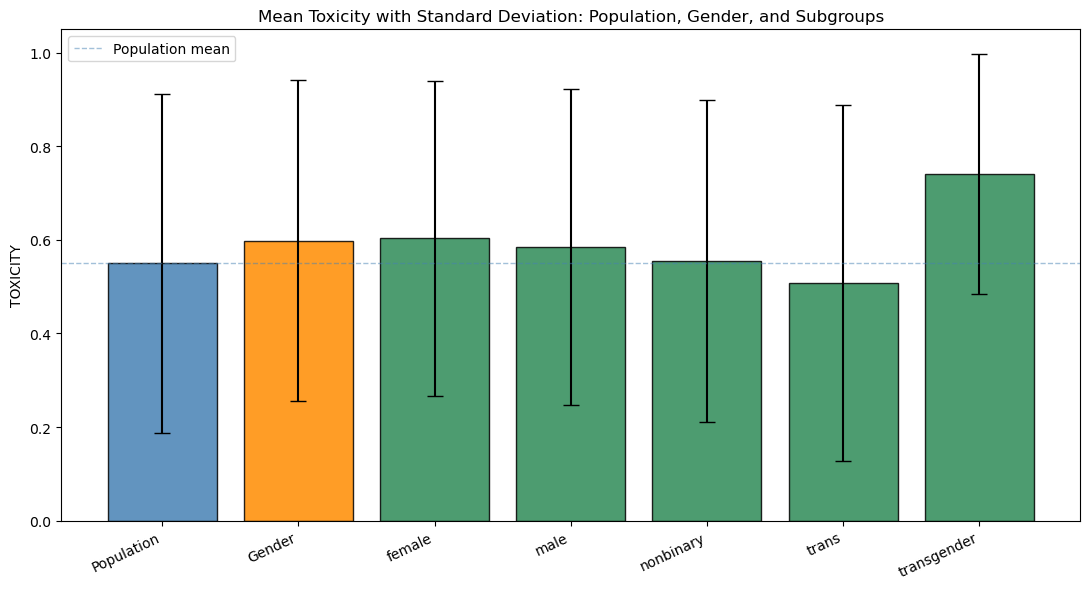

In [40]:
import matplotlib.pyplot as plt

pop_mean = df_reduced['TOXICITY'].mean()
pop_std = df_reduced['TOXICITY'].std(ddof=0)

labels = ['Population', 'Gender'] + list(gender_subgroup_pop.index)
means = [pop_mean, gender_mean] + gender_subgroup_pop['Mean'].tolist()
stds = [pop_std, gender_std] + gender_subgroup_pop['Std Dev'].tolist()

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(labels))
colors = ['steelblue', 'darkorange'] + ['seagreen'] * len(gender_subgroup_pop)

ax.bar(x, means, yerr=stds, capsize=6, color=colors, edgecolor='black', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha='right')
ax.set_ylabel('TOXICITY')
ax.set_title('Mean Toxicity with Standard Deviation: Population, Gender, and Subgroups')
ax.set_ylim(0, 1.05)
ax.axhline(pop_mean, color='steelblue', linestyle='--', linewidth=1, alpha=0.5, label='Population mean')
ax.legend()
plt.tight_layout()
plt.show()